# Notebook 4: Holdout & Incrementality Analysis

## Campaign Experimentation Framework

This notebook analyzes **EXP-003: High-Intent Segment Holdout Test**, which measures the **true incremental** impact of a campaign on opportunity creation.

### Why Holdout Testing?

Standard A/B tests measure *relative* differences between variants. But holdout testing answers a more fundamental business question: **Would these customers have converted anyway, even without the campaign?**

By withholding a random sample from the campaign, we measure:
- **Simple lift**: exposed rate − holdout rate
- **Difference-in-Differences (DiD)**: controls for pre-existing trends
- **Number Needed to Treat (NNT)**: how many contacts to reach to get one additional conversion
- **Cost per Incremental Conversion**: campaign ROI

**Dataset structure:**
- `variant`: `exposed` (received campaign) or `holdout` (no campaign)
- `period`: `baseline` (pre-campaign) or `test` (campaign period)
- Metrics: `opportunity_created`, `pipeline_value`, `days_to_opportunity`

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..")))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")

from config import SIGNIFICANCE_LEVEL, CONFIDENCE_LEVEL, VISUALS_DIR, DATA_DIR
from src.holdout_analysis import HoldoutAnalyzer
from src.visualizations import ExperimentVisualizer

DATA_PATH = PROJECT_ROOT / DATA_DIR
VISUALS_PATH = PROJECT_ROOT / VISUALS_DIR
VISUALS_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH / "exp003_holdout.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Variants: {df['variant'].value_counts().to_dict()}")
print(f"Periods: {df['period'].value_counts().to_dict()}")

Shape: (60000, 11)
Columns: ['account_id', 'variant', 'period', 'date', 'opportunity_created', 'pipeline_value', 'days_to_opportunity', 'industry', 'company_size', 'region', 'engagement_tier']
Variants: {'exposed': 48000, 'holdout': 12000}
Periods: {'baseline': 30000, 'test': 30000}


## 2. Pre-Experiment: Balance Validation

Before any analysis, we must verify that the exposed and holdout groups are statistically comparable on observed covariates. Imbalance here would bias our lift estimates.

In [2]:
analyzer = HoldoutAnalyzer(
    significance_level=SIGNIFICANCE_LEVEL,
    confidence_level=CONFIDENCE_LEVEL
)

covariates = ["industry", "company_size", "region", "engagement_tier"]

balance_results = analyzer.check_balance(
    data=df,
    variant_col="variant",
    covariates=covariates
)

print("Covariate Balance Check:")
print("-" * 65)
balance_rows = []
for b in balance_results:
    status = "BALANCED" if b.is_balanced else "IMBALANCED ***"
    print(f"  {b.variable:<20} | chi2={b.test_statistic:>8.3f} | p={b.p_value:.4f} | {status}")
    balance_rows.append({
        "Variable": b.variable,
        "Test Statistic": round(b.test_statistic, 3),
        "P-Value": round(b.p_value, 4),
        "Balanced?": b.is_balanced
    })

print()
display(pd.DataFrame(balance_rows))

Covariate Balance Check:
-----------------------------------------------------------------
  industry             | chi2=   9.802 | p=0.0439 | IMBALANCED ***
  company_size         | chi2=   2.762 | p=0.2513 | BALANCED
  region               | chi2=   0.439 | p=0.9320 | BALANCED
  engagement_tier      | chi2=   1.465 | p=0.4807 | BALANCED



,Variable,Test Statistic,P-Value,Balanced?
0,industry,9.802,0.0439,False
1,company_size,2.762,0.2513,True
2,region,0.439,0.9320,True
3,engagement_tier,1.465,0.4807,True


## 3. Parallel Trends Check

The Difference-in-Differences estimator requires that, in the *absence* of the campaign, exposed and holdout groups would have followed the same trend. We test this using pre-period data.

**Null hypothesis:** The interaction term (variant × time) is not significant in the pre-period regression — i.e., the groups had parallel trends before the campaign.

In [3]:
trends_result = analyzer.check_parallel_trends(
    panel_data=df,
    variant_col="variant",
    period_col="period",
    metric_col="opportunity_created",
    pre_period_value="baseline"
)

print(f"Parallel Trends Test — opportunity_created (baseline period)")
print(f"  Interaction p-value : {trends_result['p_value']:.4f}")
print(f"  Interaction coeff   : {trends_result['coefficient']:.6f}")
print(f"  Parallel trends?    : {trends_result['is_parallel']}")
if trends_result['is_parallel']:
    print("  => Assumption holds. DiD estimates are valid.")
else:
    print("  => WARNING: Parallel trends assumption may be violated. DiD may be biased.")

# Show mean by period and variant
plot_data = trends_result["plot_data"]
if not plot_data.empty:
    print("\nPre-period means by variant:")
    display(plot_data)

Parallel Trends Test — opportunity_created (baseline period)
  Interaction p-value : nan
  Interaction coeff   : 0.000000
  Parallel trends?    : None
  => WARNING: Parallel trends assumption may be violated. DiD may be biased.

Pre-period means by variant:


,period,variant,opportunity_created
0,baseline,exposed,0.106458
1,baseline,holdout,0.112500


## 4. Simple Lift Measurement

Simple cross-sectional lift compares exposed vs holdout during the test period only. This is the fastest estimate but doesn't account for pre-existing group differences.

In [4]:
# Test period only
test_df = df[df["period"] == "test"].copy()

simple_lift = analyzer.compute_simple_lift(
    data=test_df,
    variant_col="variant",
    metric_col="opportunity_created",
    exposed_label="exposed",
    holdout_label="holdout"
)

print("Simple Lift — opportunity_created (test period only)")
print("-" * 55)
print(f"  Exposed rate  : {simple_lift['exposed_rate']:.4f}  (n={simple_lift['n_exposed']:,})")
print(f"  Holdout rate  : {simple_lift['holdout_rate']:.4f}  (n={simple_lift['n_holdout']:,})")
print(f"  Raw lift      : {simple_lift['raw_lift']:+.4f}")
print(f"  Relative lift : {simple_lift['relative_lift_pct']:+.2f}%")
print(f"  P-value       : {simple_lift['p_value']:.4f}")
print(f"  95% CI        : [{simple_lift['ci_lower']:+.4f}, {simple_lift['ci_upper']:+.4f}]")
print(f"  Significant?  : {simple_lift['p_value'] < SIGNIFICANCE_LEVEL}")

Simple Lift — opportunity_created (test period only)
-------------------------------------------------------
  Exposed rate  : 0.1317  (n=24,000)
  Holdout rate  : 0.1228  (n=6,000)
  Raw lift      : +0.0089
  Relative lift : +7.23%
  P-value       : 0.0674
  95% CI        : [-0.0005, +0.0182]
  Significant?  : False


## 5. Difference-in-Differences

DiD controls for pre-existing group differences by using the baseline period as a counterfactual. The DiD estimator is:

$$\hat{\delta}_{DiD} = (\bar{Y}_{exposed,test} - \bar{Y}_{exposed,baseline}) - (\bar{Y}_{holdout,test} - \bar{Y}_{holdout,baseline})$$

This isolates the campaign's *incremental* effect beyond what would have happened naturally.

In [5]:
did_result = analyzer.compute_did(
    panel_data=df,
    variant_col="variant",
    period_col="period",
    metric_col="opportunity_created",
    exposed_label="exposed",
    holdout_label="holdout",
    pre_label="baseline",
    post_label="test"
)

print("Difference-in-Differences — opportunity_created")
print("-" * 55)
print("2x2 Means Table:")
display(did_result["means_table"].round(4))

print(f"\nDiD Estimate  : {did_result['did_estimate']:+.4f}")
print(f"Std Error     : {did_result['se']:.4f}")
print(f"t-statistic   : {did_result['t_stat']:.4f}")
print(f"P-value       : {did_result['p_value']:.4f}")
print(f"95% CI        : [{did_result['ci_lower']:+.4f}, {did_result['ci_upper']:+.4f}]")
print()
print("Interpretation:")
print(f"The campaign produced a {did_result['did_estimate']:+.4f} absolute lift in opportunity")
print(f"creation rate, after accounting for baseline trends (DiD estimator).")

Difference-in-Differences — opportunity_created
-------------------------------------------------------
2x2 Means Table:


period,baseline,test
variant,,
holdout,0.1125,0.1228
exposed,0.1065,0.1317



DiD Estimate  : +0.0149
Std Error     : 0.0066
t-statistic   : 2.2599
P-value       : 0.0238
95% CI        : [+0.0020, +0.0279]

Interpretation:
The campaign produced a +0.0149 absolute lift in opportunity
creation rate, after accounting for baseline trends (DiD estimator).


## 6. Full Holdout Report

In [6]:
# Run the full analysis with DiD and cost estimation
full_result = analyzer.analyze(
    data=df,
    variant_col="variant",
    metric_col="opportunity_created",
    experiment_id="EXP-003",
    period_col="period",
    campaign_cost=50_000.0,
    revenue_col="pipeline_value",
    covariates=["industry", "company_size"]
)

print(analyzer.format_holdout_report(full_result, balance_results=balance_results))

  HOLDOUT / INCREMENTALITY REPORT
  Experiment : EXP-003
  Metric     : opportunity_created
  Method     : did

SAMPLE SIZES
------------------------------------------------------------------------
  Exposed   :     48,000
  Holdout   :     12,000

CONVERSION RATES
------------------------------------------------------------------------
  Exposed rate  :   0.1191  (11.91%)
  Holdout rate  :   0.1177  (11.77%)

LIFT STATISTICS
------------------------------------------------------------------------
  Raw lift          : +0.0014
  Relative lift     : +1.20%
  95% CI (lift)  : [-0.0050, +0.0079]
  p-value           : 0.6679
  Significant       : YES  ***
  Incr. conversions : +68
  NNT               : 705.9

DIFFERENCE-IN-DIFFERENCES
------------------------------------------------------------------------
  DiD estimate : +0.0149
  DiD 95% CI  : [+0.0020, +0.0279]
  DiD p-value  : 0.0238

COST EFFICIENCY
------------------------------------------------------------------------
  Cost per i

## 7. Cost Efficiency at Different Holdout Sizes

A larger holdout group gives more statistical power but reduces campaign reach. We model the cost-efficiency trade-off across different holdout fractions.

In [7]:
holdout_fractions = [0.05, 0.10, 0.20, 0.30]
total_n = len(test_df)
campaign_cost = 50_000.0

# Use the observed lift as a fixed estimate
observed_lift = full_result.raw_lift
baseline_rate = full_result.holdout_conversion_rate

cost_rows = []
for frac in holdout_fractions:
    n_holdout  = int(total_n * frac)
    n_exposed  = total_n - n_holdout
    incr_conv  = int(round(observed_lift * n_exposed))
    cpic       = campaign_cost / incr_conv if incr_conv > 0 else float("inf")

    # Statistical power at this split
    from scipy import stats as sp
    p1 = baseline_rate
    p2 = baseline_rate + observed_lift
    p_pool = (p1 + p2) / 2
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_exposed + 1/n_holdout))
    z = abs(observed_lift) / se if se > 0 else 0
    power = float(sp.norm.sf(1.96 - z) + sp.norm.cdf(-1.96 - z))

    cost_rows.append({
        "Holdout %": f"{frac:.0%}",
        "n holdout": f"{n_holdout:,}",
        "n exposed": f"{n_exposed:,}",
        "Incr. Conversions": incr_conv,
        "Cost per Incr. Conv.": f"${cpic:,.0f}" if np.isfinite(cpic) else "N/A",
        "Statistical Power": f"{power:.2%}",
    })

cost_df = pd.DataFrame(cost_rows)
print("Cost efficiency at different holdout sizes (fixed campaign cost = $50,000):")
display(cost_df)

Cost efficiency at different holdout sizes (fixed campaign cost = $50,000):


,Holdout %,n holdout,n exposed,Incr. Conversions,Cost per Incr. Conv.,Statistical Power
0,5%,"1,500","28,500",40,"$1,250",5.31%
1,10%,"3,000","27,000",38,"$1,316",5.60%
2,20%,"6,000","24,000",34,"$1,471",6.06%
3,30%,"9,000","21,000",30,"$1,667",6.40%


## 8. Segment-Level HTE

The `compute_segment_lift()` method decomposes the overall lift by segment, revealing which subgroups drove the most (and least) incremental value from the campaign.

In [8]:
# Segment lift by industry
seg_industry = analyzer.compute_segment_lift(
    data=test_df,
    variant_col="variant",
    metric_col="opportunity_created",
    segment_col="industry",
    experiment_id="EXP-003"
)

print("Segment Lift by Industry:")
display(seg_industry[["segment", "n_exposed", "n_holdout", "segment_lift", "p_value", "is_significant", "index_vs_overall", "recommendation"]].round(4))

print("\nTop 3 segments (highest index):")
top3 = seg_industry.nlargest(3, "index_vs_overall")
for _, row in top3.iterrows():
    print(f"  {row['segment']:<20} | lift={row['segment_lift']:+.4f} | index={row['index_vs_overall']:.2f}x | {row['recommendation']}")

Segment Lift by Industry:


,segment,n_exposed,n_holdout,segment_lift,p_value,is_significant,index_vs_overall,recommendation
0,Finance,5275,1282,0.0064,0.5322,False,0.7195,REDUCE_INVESTMENT
1,Healthcare,4888,1206,0.0132,0.2353,False,1.4919,REDUCE_INVESTMENT
2,Manufacturing,2332,592,-0.0009,0.9551,False,-0.1002,EXCLUDE
3,Retail,4319,1149,0.0174,0.1145,False,1.9592,REDUCE_INVESTMENT
4,Technology,7186,1771,0.0055,0.5377,False,0.6167,REDUCE_INVESTMENT



Top 3 segments (highest index):
  Retail               | lift=+0.0174 | index=1.96x | REDUCE_INVESTMENT
  Healthcare           | lift=+0.0132 | index=1.49x | REDUCE_INVESTMENT
  Finance              | lift=+0.0064 | index=0.72x | REDUCE_INVESTMENT


In [9]:
# Segment lift by company_size
seg_size = analyzer.compute_segment_lift(
    data=test_df,
    variant_col="variant",
    metric_col="opportunity_created",
    segment_col="company_size",
    experiment_id="EXP-003"
)

print("Segment Lift by Company Size:")
display(seg_size[["segment", "n_exposed", "n_holdout", "segment_lift", "p_value", "is_significant", "index_vs_overall", "recommendation"]].round(4))

print("\nBottom segment (lowest index / possible REDUCE):")
bottom = seg_size.nsmallest(1, "index_vs_overall")
for _, row in bottom.iterrows():
    print(f"  {row['segment']:<20} | lift={row['segment_lift']:+.4f} | index={row['index_vs_overall']:.2f}x | {row['recommendation']}")

Segment Lift by Company Size:


,segment,n_exposed,n_holdout,segment_lift,p_value,is_significant,index_vs_overall,recommendation
0,Enterprise,5896,1507,-0.0022,0.8200,False,-0.2469,EXCLUDE
1,Mid-Market,8377,2050,0.0232,0.0069,True,2.6127,INCREASE_INVESTMENT
2,SMB,9727,2443,0.0033,0.6528,False,0.3746,REDUCE_INVESTMENT



Bottom segment (lowest index / possible REDUCE):
  Enterprise           | lift=-0.0022 | index=-0.25x | EXCLUDE


## 9. Incrementality Visualization

Holdout comparison plot saved: C:\Users\syeda\campaign-experimentation-framework\visuals\EXP-003_holdout_opportunity_created.png


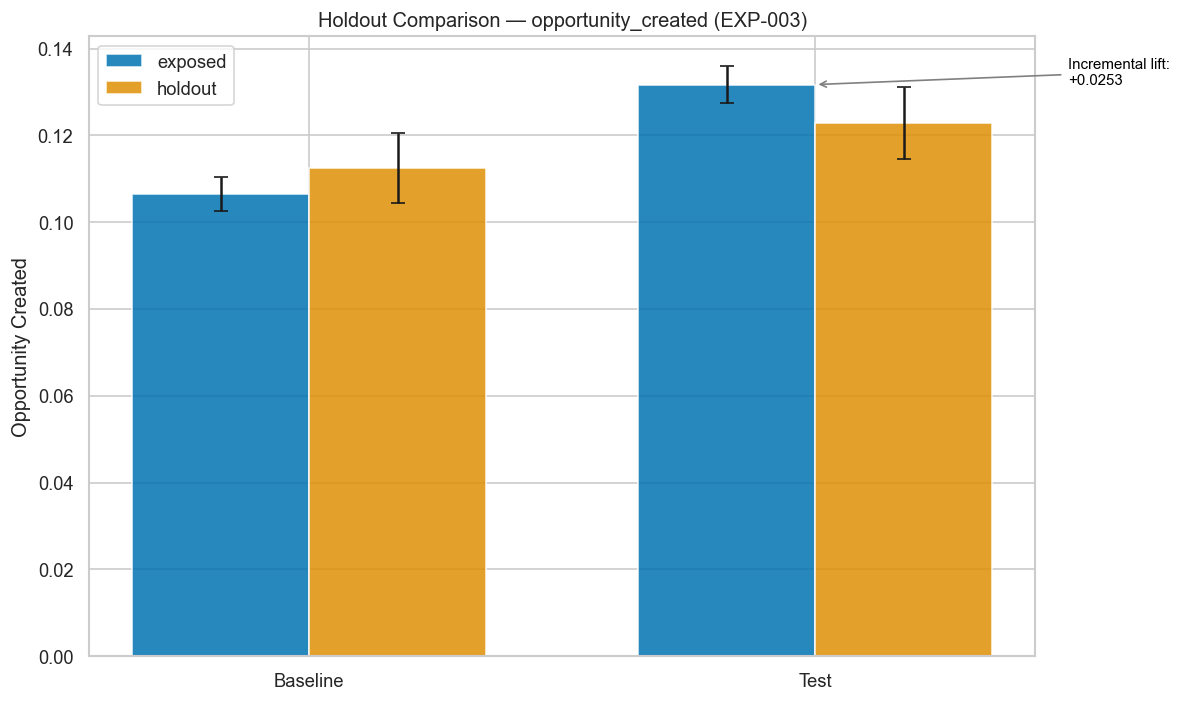

In [10]:
visualizer = ExperimentVisualizer(visuals_dir=VISUALS_PATH)

# Build the period_means DataFrame for the holdout comparison plot
period_means_rows = []
for period in ["baseline", "test"]:
    for variant in ["exposed", "holdout"]:
        sub = df[(df["period"] == period) & (df["variant"] == variant)]["opportunity_created"]
        if len(sub) == 0:
            continue
        mean_val = sub.mean()
        n = len(sub)
        se = sub.std(ddof=1) / np.sqrt(n) if n > 1 else 0
        z = 1.96
        period_means_rows.append({
            "period": period,
            "variant": variant,
            "mean": mean_val,
            "ci_lower": mean_val - z * se,
            "ci_upper": mean_val + z * se,
        })

period_means_df = pd.DataFrame(period_means_rows)

holdout_plot_path = visualizer.plot_holdout_comparison(
    period_means=period_means_df,
    experiment_id="EXP-003",
    metric_name="opportunity_created"
)
print(f"Holdout comparison plot saved: {holdout_plot_path}")
display(Image(filename=holdout_plot_path))